<a href="https://colab.research.google.com/github/TiferetChayahShalom/DI_Bootcamp/blob/main/week10/Day2/Tiferet__Exercises_XP_Ninja_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP Ninja: Guided Student Notebook

This guided notebook follows the **exact exercise on the platform**. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points are included only when a concept is important for intuition or transfer to other AI topics.


## Reference from the exercise

**What you will learn**  
- How to implement a deep neural network from scratch.
- How to optimize weight updates using advanced backpropagation techniques.
- How to fine tune hyperparameters and activation functions for better model performance.

**What you will create**  
- A fully connected deep neural network without using high level deep learning libraries.
- A manual backpropagation algorithm with vectorized computations.
- A neural network that learns through an optimized training loop.


## Exercise 1: Building a Deep Neural Network Without Keras or TensorFlow

**As stated in the exercise**  
Task: Implement a fully connected deep neural network from scratch using only NumPy. The model has three layers input, two hidden, and output. Use the ReLU activation function for hidden layers and Softmax for multi class classification. Compute both forward and backward propagation manually.  
Given data. Input features are a dataset with four numerical features. Number of classes is three. Number of hidden neurons is five for the first hidden layer and four for the second hidden layer. Learning rate is 0.01.

Steps: Initialize weights and biases for all layers. Implement forward propagation. Implement the Softmax function for the output layer. Compute the loss using categorical cross entropy. Implement backpropagation using matrix operations. Update weights and biases using gradient descent. Train the network for multiple iterations and evaluate performance.

**Guidance**  
Work with shapes. X is (N, 4). One hot targets Y are (N, 3). Parameter shapes: W1 (4, 5), b1 (5,), W2 (5, 4), b2 (4,), W3 (4, 3), b3 (3,). Use stable Softmax with logits shift by max per row. For cross entropy, average negative log likelihood over the batch.

**Learning point**  
Softmax plus cross entropy has a compact gradient: dZ3 equals Yhat minus Y. ReLU derivative is 1 on positives and 0 on non positives. Vectorize all operations to avoid slow loops.


In [ ]:
# PREFILLED: just execute
import numpy as np

rng = np.random.default_rng(123)

# Synthetic dataset generator for 3 classes in 4D
def make_blob_4d(n_per_class=200, spread=0.8):
    centers = np.array([
        [ 2.0,  2.0,  0.0,  0.5],
        [-2.0,  1.5,  1.0, -0.5],
        [ 0.0, -2.0, -1.5,  1.0],
    ])
    X_list, y_list = [], []
    for k, c in enumerate(centers):
        Xk = rng.normal(loc=c, scale=spread, size=(n_per_class, 4))
        yk = np.full(n_per_class, k, dtype=int)
        X_list.append(Xk); y_list.append(yk)
    X = np.vstack(X_list)
    y = np.concatenate(y_list)
    # shuffle
    idx = rng.permutation(len(y))
    return X[idx], y[idx]

# Train and test split
X_all, y_all = make_blob_4d(n_per_class=150, spread=0.9)
N = X_all.shape[0]
split = int(0.8 * N)
X_train, y_train = X_all[:split], y_all[:split]
X_test,  y_test  = X_all[split:], y_all[split:]

# One hot
def one_hot(y, num_classes=3):
    Y = np.zeros((y.shape[0], num_classes), dtype=float)
    Y[np.arange(y.shape[0]), y] = 1.0
    return Y

Y_train = one_hot(y_train, 3)
Y_test  = one_hot(y_test, 3)

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((360, 4), (360, 3), (90, 4), (90, 3))

In [ ]:
# PREFILLED: just execute
# Standardize inputs to zero mean unit variance for stable training
mu = X_train.mean(axis=0, keepdims=True)
sd = X_train.std(axis=0, keepdims=True) + 1e-8
X_train_std = (X_train - mu) / sd
X_test_std  = (X_test  - mu) / sd

print("Means:", mu.ravel())
print("Stds:", sd.ravel())

Means: [-0.01314787  0.48525324 -0.06843803  0.31093986]
Stds: [1.93296348 1.98620559 1.38844722 1.07442903]


In [8]:
# To-Do: implement ReLU, ReLU derivative, stable softmax, and cross entropy loss
def relu(x):
  return np.maximum(0.0, x)



def drelu(x):
    return (x > 0).astype(float)



def softmax(logits):
  # Subtract row-wise max for numerical stability
  shifted = logits - np.max(logits, axis=1, keepdims=True)
  exp_values = np.exp(shifted)
  return exp_values / np.sum(exp_values, axis=1, keepdims=True)



def cross_entropy(probs, Y_true):
# Average negative log likelihood
 eps = 1e-12
 probs = np.clip(probs, eps,1.0)
 loss = -np.sum(Y_true * np.log(probs)) / Y_true.shape[0]
 return loss

In [9]:
# PREFILLED: just execute
D, H1, H2, C = 4, 5, 4, 3
lr = 0.01

# He initialization for ReLU layers, Xavier for output
W1 = rng.normal(0.0, np.sqrt(2.0/D), size=(D, H1)); b1 = np.zeros(H1)
W2 = rng.normal(0.0, np.sqrt(2.0/H1), size=(H1, H2)); b2 = np.zeros(H2)
W3 = rng.normal(0.0, np.sqrt(1.0/H2), size=(H2, C));  b3 = np.zeros(C)

params = dict(W1=W1, b1=b1, W2=W2, b2=b2, W3=W3, b3=b3)

for k,v in params.items():
    if k.startswith('W'):
        print(k, v.shape)

W1 (4, 5)
W2 (5, 4)
W3 (4, 3)


In [20]:
# To-Do: implement forward propagation
def forward(X, params):
  W1, b1 = params["W1"], params["b1"]
  W2, b2 = params["W2"], params["b2"]
  W3, b3 = params["W3"], params["b3"]

  # Layer 1
  Z1 = X @ W1 + b1
  A1 = relu(Z1)

  # Layer 2
  Z2 = A1 @ W2 + b2
  A2 = relu(Z2)

  # Output layer
  Z3 = A2 @ W3 + b3
  Yhat = softmax(Z3)

  return {
    "Z1": Z1,
    "A1": A1,
    "Z2": Z2,
    "A2": A2,
    "Z3": Z3,
    "Yhat": Yhat
  }

In [21]:
# To-Do: implement backward propagation using matrix calculus
def backward(X, Y, cache, params):
  N = X.shape[0]

  W2 = params["W2"]
  W3 = params["W3"]

  Z1 = cache["Z1"]
  A1 = cache["A1"]
  Z2 = cache["Z2"]
  A2 = cache["A2"]
  Yhat = cache["Yhat"]

  # Output layer
  dZ3 = Yhat - Y
  dW3 = A2.T @ dZ3 / N
  db3 = dZ3.mean(axis=0)

  # Hidden layer 2
  dA2 = dZ3 @ W3.T
  dZ2 = dA2 * drelu(Z2)
  dW2 = A1.T @ dZ2 / N
  db2 = dZ2.mean(axis=0)

  # Hidden layer 1
  dA1 = dZ2 @ W2.T
  dZ1 = dA1 * drelu(Z1)
  dW1 = X.T @ dZ1 / N
  db1 = dZ1.mean(axis=0)

  return {
    "dW1": dW1,
    "db1": db1,
    "dW2": dW2,
    "db2": db2,
    "dW3": dW3,
    "db3": db3
  }

In [12]:
# PREFILLED: just execute
def sgd_update(params, grads, lr):
    for k in ['W1','b1','W2','b2','W3','b3']:
        params[k] = params[k] - lr * grads['d'+k]
    return params


In [24]:
# To-Do: implement the training loopimport matpotlib.pyplot as plt
epochs = 200

for t in range(epochs):
  # Forward propagation
  cache = forward(X_train_std, params)

  # Calculate loss
  loss = cross_entropy(cache["Yhat"], Y_train)

  # Backward propagation
  grads = backward(X_train_std, Y_train, cache, params)

  # Update parameters
  params = sgd_update(params, grads, lr)

  # Print results every 20 epochs
  if (t + 1) % 20 == 0:
    train_cache = forward(X_train_std, params)
    test_cache = forward(X_test_std, params)

    acc_tr = (
    train_cache["Yhat"].argmax(axis=1)
    == Y_train.argmax(axis=1)
    ).mean()

    acc_te = (
      test_cache["Yhat"].argmax(axis=1)
      == Y_test.argmax(axis=1)
      ).mean()

    print(
    f"epoch={t+1} loss={loss:.4f} "
    f"acc_train={acc_tr:.3f} acc_test={acc_te:.3f}"
    )


epoch=20 loss=0.5949 acc_train=0.803 acc_test=0.767
epoch=40 loss=0.5668 acc_train=0.817 acc_test=0.767
epoch=60 loss=0.5409 acc_train=0.836 acc_test=0.800
epoch=80 loss=0.5171 acc_train=0.847 acc_test=0.800
epoch=100 loss=0.4954 acc_train=0.861 acc_test=0.833
epoch=120 loss=0.4754 acc_train=0.867 acc_test=0.844
epoch=140 loss=0.4569 acc_train=0.883 acc_test=0.856
epoch=160 loss=0.4397 acc_train=0.889 acc_test=0.856
epoch=180 loss=0.4238 acc_train=0.892 acc_test=0.878
epoch=200 loss=0.4089 acc_train=0.906 acc_test=0.889


In [23]:
# To-Do: final evaluation and confusion like summary
def accuracy(probs, Y_true):
  yhat = probs.argmax(axis=1)
  ytrue = Y_true.argmax(axis=1)
  return (yhat == ytrue).mean()

cache = forward(X_test_std, params)

test_acc = accuracy(cache["Yhat"], Y_test)

print("Test accuracy:", test_acc)

Test accuracy: 0.7777777777777778


**To-Do:** Plot the training loss by epoch and the train and test accuracy by epoch in two separate figures. Use Matplotlib.


In [25]:
import matplotlib.pyplot as plt

epochs = 200

loss_history = []
train_acc_history = []
test_acc_history = []

for t in range(epochs):
  # Forward
  cache = forward(X_train_std, params)
  loss = cross_entropy(cache["Yhat"], Y_train)

  # Backward and update
  grads = backward(X_train_std, Y_train, cache, params)
  params = sgd_update(params, grads, lr)

  # Calculate train and test accuracy
  train_cache = forward(X_train_std, params)
  test_cache = forward(X_test_std, params)

  acc_tr = accuracy(train_cache["Yhat"], Y_train)
  acc_te = accuracy(test_cache["Yhat"], Y_test)

  # Save values for plotting
  loss_history.append(loss)
  train_acc_history.append(acc_tr)
  test_acc_history.append(acc_te)

  if (t + 1) % 20 == 0:
    print(
      f"epoch={t+1} loss={loss:.4f} "
      f"acc_train={acc_tr:.3f} "
      f"acc_test={acc_te:.3f}"
      )

epoch=20 loss=0.3950 acc_train=0.906 acc_test=0.889
epoch=40 loss=0.3819 acc_train=0.914 acc_test=0.889
epoch=60 loss=0.3695 acc_train=0.922 acc_test=0.900
epoch=80 loss=0.3578 acc_train=0.928 acc_test=0.900
epoch=100 loss=0.3467 acc_train=0.939 acc_test=0.911
epoch=120 loss=0.3363 acc_train=0.944 acc_test=0.911
epoch=140 loss=0.3264 acc_train=0.947 acc_test=0.911
epoch=160 loss=0.3170 acc_train=0.947 acc_test=0.933
epoch=180 loss=0.3080 acc_train=0.950 acc_test=0.933
epoch=200 loss=0.2995 acc_train=0.950 acc_test=0.933


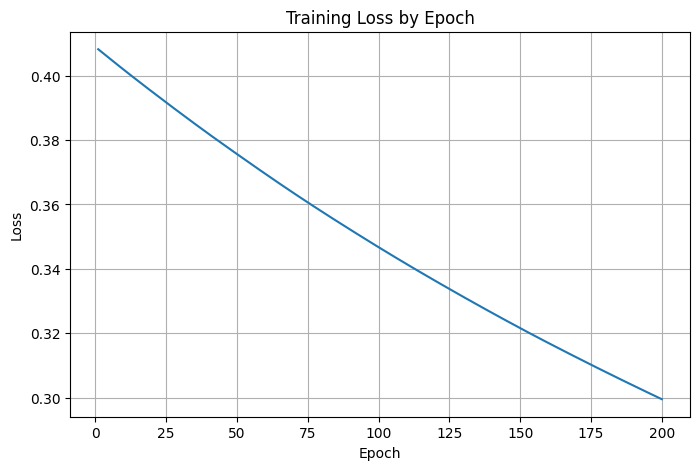

In [26]:
# Figure 1: Training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss by Epoch")
plt.grid(True)
plt.show()

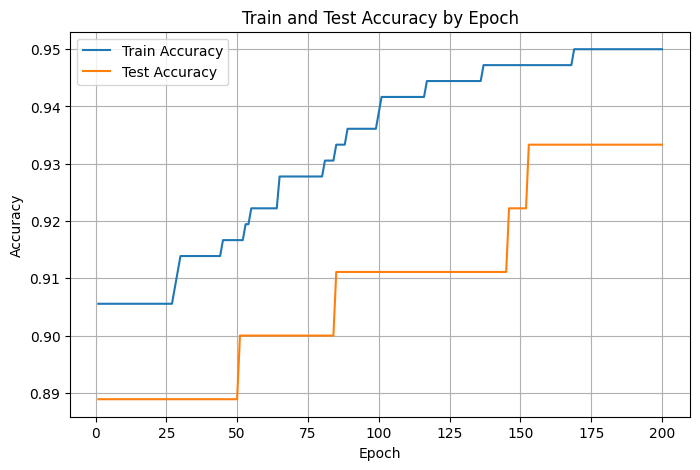

In [27]:
# Figure 2: Train and test accuracy
plt.figure(figsize=(8, 5))

plt.plot(range(1, epochs + 1),
  train_acc_history,label="Train Accuracy")

plt.plot(range(1, epochs + 1),
  test_acc_history,label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train and Test Accuracy by Epoch")
plt.legend()
plt.grid(True)
plt.show()

**Learning point**  
Softmax cross entropy surfaces are smooth. Full batch reduces gradient variance but can be slow. Mini batch introduces noise that can help escape shallow minima.


## Exercise 2: Optimizing Backpropagation with Momentum

**As stated in the exercise**  
Task: Implement backpropagation with momentum to improve gradient updates and accelerate learning. Momentum helps prevent oscillations in gradient descent by maintaining a velocity term.  
Given data. A dataset with two numerical input features. A two layer neural network with a first layer of four neurons with ReLU activation and an output layer of one neuron with Sigmoid activation. Initial weights and biases are given. Momentum coefficient is 0.9. Learning rate is 0.005.  

Steps: Implement standard backpropagation to compute gradients. Modify gradient updates to include momentum. Update weights using the momentum based learning rule. Compare training speed with and without momentum. Interpret how momentum affects the convergence rate.

**Guidance**  
Use a synthetic binary classification dataset. Parameters: W1 (2, 4), b1 (4,), W2 (4, 1), b2 (1,). For momentum, maintain velocity variables with same shapes and update v equals beta times v plus gradient. Then update parameters by subtracting learning rate times v.

**Learning point**  
Momentum is a low pass filter on gradients. It accelerates along shallow consistent directions and damps zigzagging in narrow valleys.

![image.png](https://github.com/user-attachments/assets/a061101f-f709-4a6d-9fa8-383077ca94a9)


In [28]:
# PREFILLED: just execute
import numpy as np

rng2 = np.random.default_rng(99)

def make_two_moons_linear(n=400):
    # Two clusters in 2D for simple nonlinear boundary
    A = rng2.normal([1.5, 0.0], [0.8, 0.8], size=(n//2, 2))
    B = rng2.normal([-1.5, 0.0], [0.8, 0.8], size=(n//2, 2))
    X = np.vstack([A, B])
    y = np.concatenate([np.ones(n//2, dtype=int), np.zeros(n//2, dtype=int)])
    idx = rng2.permutation(n); X, y = X[idx], y[idx]
    # standardize
    mu = X.mean(axis=0, keepdims=True); sd = X.std(axis=0, keepdims=True) + 1e-8
    return (X - mu)/sd, y.reshape(-1,1).astype(float)

X2, y2 = make_two_moons_linear(500)
X2.shape, y2.shape

((500, 2), (500, 1))

In [29]:
# To-Do: implement relu, drelu, sigmoid, and binary cross entropy
def relu(x):
  return np.maximum(0, x)

def drelu(x):
  return (x > 0).astype(float)

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def bce(p, y):
  eps = 1e-8
  return -np.mean(
    y * np.log(p + eps) +
    (1 - y) * np.log(1 - p + eps)
    )

In [30]:
# PREFILLED: just execute
D, H, O = 2, 4, 1
W1 = rng2.normal(0.0, np.sqrt(2.0/D), size=(D,H)); b1 = np.zeros(H)
W2 = rng2.normal(0.0, np.sqrt(2.0/H), size=(H,O)); b2 = np.zeros(O)
params2 = dict(W1=W1,b1=b1,W2=W2,b2=b2)
lr = 0.005
beta = 0.9

# Velocities for momentum
vel2 = {k: np.zeros_like(v) for k,v in params2.items()}

In [33]:
# To-Do: implement forward and backward for the 2 layer net
def forward2(X, params):
  W1, b1 = params["W1"], params["b1"]
  W2, b2 = params["W2"], params["b2"]

  Z1 = X @ W1 + b1
  A1 = relu(Z1)

  Z2 = A1 @ W2 + b2
  P = sigmoid(Z2)

  return {"Z1": Z1, "A1": A1, "Z2": Z2, "P": P}


def backward2(X, y, cache, params):
  N = X.shape[0]

  W2 = params["W2"]
  Z1 = cache["Z1"]
  A1 = cache["A1"]
  P = cache["P"]

  dZ2 = P - y

  dW2 = A1.T @ dZ2 / N
  db2 = dZ2.mean(axis=0)

  dA1 = dZ2 @ W2.T
  dZ1 = dA1 * drelu(Z1)

  dW1 = X.T @ dZ1 / N
  db1 = dZ1.mean(axis=0)

  return {
    "dW1": dW1,
    "db1": db1,
    "dW2": dW2,
    "db2": db2
      }



def predict2(P):
  return (P >= 0.5).astype(int)


In [34]:
# To-Do: implement parameter updates
def sgd_update2(params, grads, lr):
  for k in params:
    params[k] = params[k] - lr * grads['d' + k]
  return params



def momentum_update2(params, grads, vel, lr, beta):
  for k in params:
    vel[k] = beta * vel[k] + grads['d' + k]
    params[k] = params[k] - lr * vel[k]
  return params, vel

In [35]:
# To-Do: train two copies of the model for T epochs: one with SGD, one with momentum
T = 300
lr = 0.01
beta = 0.9

losses_sgd, losses_mom = [], []

# Make separate copies of the starting parameters
params_sgd = {k: v.copy() for k, v in params2.items()}
params_mom = {k: v.copy() for k, v in params2.items()}

# Initialize momentum velocity
vel_mom = {k: np.zeros_like(v) for k, v in params_mom.items()}

for t in range(T):

  # ----- SGD -----
  cache_sgd = forward2(X2, params_sgd)
  loss_sgd = bce(cache_sgd["P"], y2)

  grads_sgd = backward2(X2, y2, cache_sgd, params_sgd)
  params_sgd = sgd_update2(params_sgd, grads_sgd, lr)

  losses_sgd.append(loss_sgd)

  # ----- Momentum -----
  cache_mom = forward2(X2, params_mom)
  loss_mom = bce(cache_mom["P"], y2)

  grads_mom = backward2(X2, y2, cache_mom, params_mom)

  params_mom, vel_mom = momentum_update2(
  params_mom,
  grads_mom,
  vel_mom,
  lr,
  beta
  )

  losses_mom.append(loss_mom)

print("ready to plot training curves")

ready to plot training curves


**To-Do:** Plot both loss curves in one figure and compare the initial convergence rate. Explain in two sentences how momentum changes the trajectory.


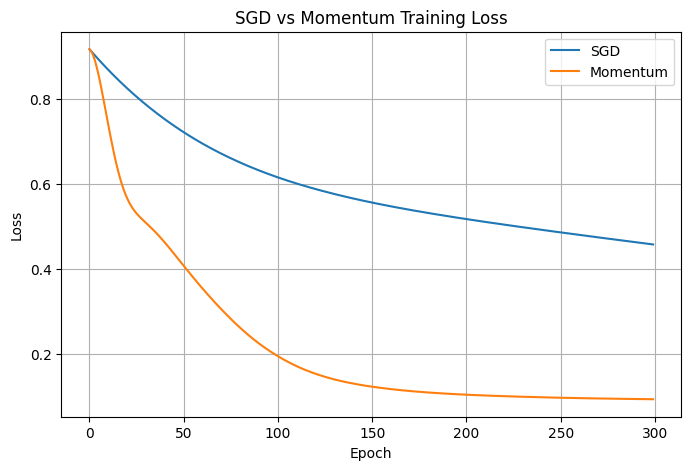

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(losses_sgd, label="SGD")
plt.plot(losses_mom, label="Momentum")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SGD vs Momentum Training Loss")
plt.legend()
plt.grid(True)

plt.show()

## Exercise 3: Fine Tuning Activation Functions for an Image Classifier

**As stated in the exercise**  
Task: Experiment with different activation functions to optimize the performance of a convolutional neural network on an image dataset.  
Given data. A dataset of grayscale images of size 28 by 28 pixels with ten categories. A CNN architecture with two convolutional layers, one fully connected layer, and a softmax output layer. The ability to switch activation functions ReLU, Leaky ReLU, and Swish.  

Steps: Train the CNN using ReLU activation and record accuracy. Train the same CNN using Leaky ReLU and compare results. Train the CNN using Swish activation and analyze the effect. Evaluate model performance on test data for all cases. Interpret which activation function works best and why.

**Guidance**  
Use TensorFlow or Keras for this exercise so you focus on the activation comparison rather than low level convolution code. Implement a function that builds the same architecture with a parameter that chooses the activation layer. Ensure identical training settings across runs to isolate the activation effect.

**Learning point**  
Activations trade off sparsity, gradient flow, and smoothness. Leaky ReLU avoids dead neurons. Swish can improve accuracy at modest extra compute due to its smooth gating.



In [37]:
# PREFILLED: just execute
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

print("TensorFlow:", tf.__version__)
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32")/255.0
x_test  = x_test.astype("float32")/255.0
x_train = np.expand_dims(x_train, -1)  # (N,28,28,1)
x_test  = np.expand_dims(x_test,  -1)
y_train_oh = to_categorical(y_train, 10)
y_test_oh  = to_categorical(y_test,  10)
x_train.shape, y_train_oh.shape

TensorFlow: 2.21.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((60000, 28, 28, 1), (60000, 10))

In [38]:
# To-Do: implement build_cnn(activation_name) returning a compiled model
# Allowed activations: 'relu', 'leaky_relu', 'swish'
# Hints: use layers.LeakyReLU(alpha=0.1) and tf.nn.swish or layers.Activation('swish')
def build_cnn(act='relu'):
  inputs = layers.Input(shape=(28, 28, 1))

  # First convolution
  x = layers.Conv2D(32, 3, padding='same')(inputs)

  if act == 'relu':
    x = layers.ReLU()(x)
  elif act == 'leaky_relu':
    x = layers.LeakyReLU(negative_slope=0.1)(x)
  elif act == 'swish':
    x = layers.Activation('swish')(x)
  else:
    raise ValueError('unknown activation')

  x = layers.MaxPooling2D()(x)

  # Second convolution
  x = layers.Conv2D(64, 3, padding='same')(x)

  if act == 'relu':
    x = layers.ReLU()(x)
  elif act == 'leaky_relu':
    x = layers.LeakyReLU(negative_slope=0.1)(x)
  elif act == 'swish':
    x = layers.Activation('swish')(x)

    x = layers.MaxPooling2D()(x)

  # Classification
  x = layers.Flatten()(x)
  x = layers.Dense(128)(x)

  if act == 'relu':
    x = layers.ReLU()(x)
  elif act == 'leaky_relu':
    x = layers.LeakyReLU(negative_slope=0.1)(x)
  elif act == 'swish':
    x = layers.Activation('swish')(x)

  outputs = layers.Dense(10, activation='softmax')(x)

  model = tf.keras.Model(inputs=inputs, outputs=outputs)

  model.compile(
  optimizer='adam',
  loss='categorical_crossentropy',
  metrics=['accuracy']
  )

  return model

In [39]:
# To-Do: train three models with identical epochs and batch size
results = {}

for act in ['relu', 'leaky_relu', 'swish']:
  print(f"Training with {act}...")

  model = build_cnn(act)

  hist = model.fit(
  x_train,
  y_train_oh,
  validation_split=0.1,
  epochs=2,
  batch_size=128,
  verbose=2
  )

  test_loss, test_acc = model.evaluate(
    x_test,
    y_test_oh,
    verbose=0
    )

  results[act] = dict(
    test_acc=float(test_acc),
    history=hist.history
    )

results

Training with relu...
Epoch 1/2
422/422 - 64s - 152ms/step - accuracy: 0.9509 - loss: 0.1642 - val_accuracy: 0.9807 - val_loss: 0.0748
Epoch 2/2
422/422 - 84s - 198ms/step - accuracy: 0.9864 - loss: 0.0446 - val_accuracy: 0.9882 - val_loss: 0.0454
Training with leaky_relu...
Epoch 1/2
422/422 - 66s - 156ms/step - accuracy: 0.9485 - loss: 0.1722 - val_accuracy: 0.9860 - val_loss: 0.0481
Epoch 2/2
422/422 - 82s - 194ms/step - accuracy: 0.9859 - loss: 0.0463 - val_accuracy: 0.9883 - val_loss: 0.0453
Training with swish...
Epoch 1/2
422/422 - 70s - 166ms/step - accuracy: 0.9233 - loss: 0.2497 - val_accuracy: 0.9825 - val_loss: 0.0677
Epoch 2/2
422/422 - 69s - 163ms/step - accuracy: 0.9824 - loss: 0.0564 - val_accuracy: 0.9885 - val_loss: 0.0432


{'relu': {'test_acc': 0.9886999726295471,
  'history': {'accuracy': [0.9509259462356567, 0.9864259362220764],
   'loss': [0.16420160233974457, 0.04460260272026062],
   'val_accuracy': [0.9806666374206543, 0.9881666898727417],
   'val_loss': [0.07476834207773209, 0.04543968662619591]}},
 'leaky_relu': {'test_acc': 0.9872999787330627,
  'history': {'accuracy': [0.9484815001487732, 0.9859444499015808],
   'loss': [0.17222510278224945, 0.04634152725338936],
   'val_accuracy': [0.9860000014305115, 0.9883333444595337],
   'val_loss': [0.04808167368173599, 0.04526408016681671]}},
 'swish': {'test_acc': 0.9854999780654907,
  'history': {'accuracy': [0.9233333468437195, 0.9824444651603699],
   'loss': [0.249659463763237, 0.05639999732375145],
   'val_accuracy': [0.9825000166893005, 0.9884999990463257],
   'val_loss': [0.06771502643823624, 0.04316020756959915]}}}

**To-Do:** Create a bar chart of test accuracy for each activation. Summarize in four sentences the trade offs observed.


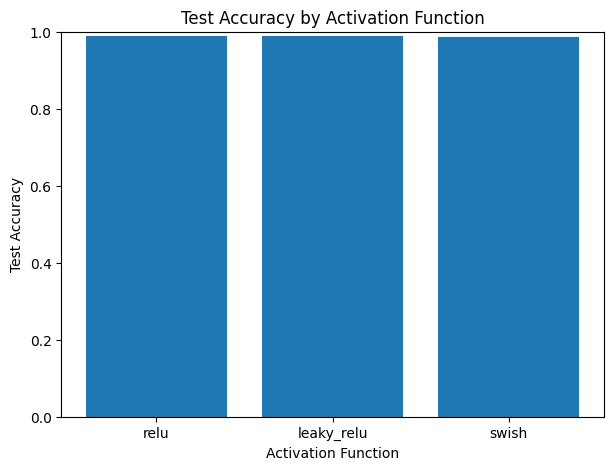

In [40]:
import matplotlib.pyplot as plt

activations = list(results.keys())
accuracies = [results[a]['test_acc'] for a in activations]

plt.figure(figsize=(7, 5))
plt.bar(activations, accuracies)

plt.xlabel("Activation Function")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy by Activation Function")
plt.ylim(0, 1)

plt.show()

## Conclusion

You implemented a deep network from scratch, optimized training with momentum, and compared activation functions in a CNN. For additional challenges, try implementing batch normalization or dropout for regularization, and compare their impact on convergence and accuracy.
